# Welcome to the flakes-polymer onboarding tutorial!
This tutorial will introduce you to the basics of running a simulation by introducing how to create a simple bead-spring model by making chain(s) of carbon molecules.

## Begin by importing all the necessary libraries

In [1]:
import warnings
import mbuild as mb
import unyt as u
import numpy as np
import hoomd
import flowermd
from cmeutils.visualize import FresnelGSD
from flowermd.base import Pack, Simulation, System, Molecule
from flowermd.library.forcefields import BeadSpring
from flowermd.utils import get_target_box_number_density
warnings.filterwarnings('ignore')

/Users/joselyngutierrez/miniconda3/envs/flowermd-dev/lib/python3.12/site-packages/gmso/core/element.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## Specify which device type you are using
These simulations will be ran on both a CPU and a GPU, so ensure you are adjusting your device type when necessary.

In [2]:
cpu = hoomd.device.CPU()

## Creating the chain 
Create a class using an mbuild compound to create a chain of the desired length.
To change the length adjust the the range value.

In [3]:
class CC(mb.Compound):
    def __init__(self):
        super(CC, self).__init__()

        for i in range(10):
            self.add(mb.Particle(name="C", pos=[i,0,0]))
            if i>0:
                self.add_bond((self[-2],self[-1]))
CarbonBond = CC()

## Number of chains
Now that the compound has been created you can adjust the amount of chains you would like in your system. 

In [18]:
N_chains = 2 #Not currently adjustable, need to fix

## Packing your system
For these types of simulations the molecules are packed into a box which allows us to control their density. Here you will see a visual of the carbon chain created above.  

In [17]:
system = Pack(molecules=[CarbonBond], density=0.5*u.Unit("nm**-3"), packing_expand_factor=5)
system.visualize()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Forcefield 
A forcefield is necessary to include the interactions that will occur in the system. For this forcefield a bead-spring interaction was set with the Lennard-Jones potential (r_cut=2.5) to model attractive forces. The r_cut value is the distance within which particles interact with each other. 

In [6]:
ff = BeadSpring(
    r_cut=2.5, 
    beads={"C": dict(epsilon=1.0, sigma=1.0)}, 
    bonds={"C-C": dict(r0=1.0, k=300)},  
    angles={},
    dihedrals={} 
)

## Additional parameters 
For the simulation we may want to adjust the dt value which is the size of one step and the temperature which is the average kinetic energy of the particles in the system. Additionally, we can set a specific final density. 

In [7]:
dt = 0.005
temp = 3
final_dens = 0.3

## Target box
Create a target box to state the desired final density needed.

In [8]:
target_box = get_target_box_number_density(density=final_dens*u.Unit("nm**-3"), n_beads=(500+(N_chains*10)))

## Output files 
We will want to create our output files prior to running our simulation to ensure we are storing all the necessary information. The gsd file will be used for additional visualization purposes (ex. Ovitio) and the log files are the text files that store necessary information. 

In [9]:
gsd = f"carbon_chain.gsd"
log = f"carbon_chain.txt"

## Simulation
Necessary things to run a simulation are initial state, forcefield, device, dt, write frequency, and output files. We run an upadate volume sim to get to the final parameters. In sim.run_NVT, is where you will specify how many steps you would like to run for and temp. After running this cell the simulation will start. 

In [10]:
sim = Simulation(
    initial_state=system.hoomd_snapshot, forcefield=ff.hoomd_forces, device=cpu, dt = dt, gsd_write_freq=int(10000), log_file_name = log, gsd_file_name = gsd
)
sim.run_update_volume(final_box_lengths=target_box, kT=6.0, n_steps=1e6,tau_kt=100*sim.dt,period=10,thermalize_particles=True)
sim.run_NVT(n_steps=1e6, kT=temp, tau_kt=dt*100)
sim.flush_writers()

Initializing simulation state from a gsd.hoomd.Frame.
Step 5500 of 1000000; TPS: 56259.65; ETA: 0.3 minutes
Step 11000 of 1000000; TPS: 108464.15; ETA: 0.2 minutes
Step 16500 of 1000000; TPS: 157226.71; ETA: 0.1 minutes
Step 22000 of 1000000; TPS: 202714.53; ETA: 0.1 minutes
Step 27500 of 1000000; TPS: 245500.64; ETA: 0.1 minutes
Step 33000 of 1000000; TPS: 285452.31; ETA: 0.1 minutes
Step 38500 of 1000000; TPS: 323322.92; ETA: 0.0 minutes
Step 44000 of 1000000; TPS: 358624.51; ETA: 0.0 minutes
Step 49500 of 1000000; TPS: 392446.01; ETA: 0.0 minutes
Step 55000 of 1000000; TPS: 424209.24; ETA: 0.0 minutes
Step 60500 of 1000000; TPS: 454538.62; ETA: 0.0 minutes
Step 66000 of 1000000; TPS: 482784.35; ETA: 0.0 minutes
Step 71500 of 1000000; TPS: 509938.45; ETA: 0.0 minutes
Step 77000 of 1000000; TPS: 535913.14; ETA: 0.0 minutes
Step 82500 of 1000000; TPS: 560290.67; ETA: 0.0 minutes
Step 88000 of 1000000; TPS: 583678.23; ETA: 0.0 minutes
Step 93500 of 1000000; TPS: 606111.68; ETA: 0.0 minu

## Visualizing final frame
Once the simulation is complete we can visualize the final frame. If you would like to vizualize the entire simulation, open the gsd file in Ovito. 

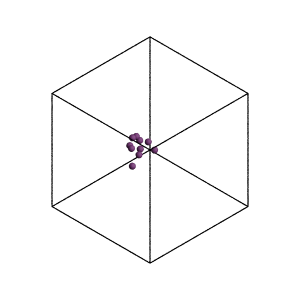

In [11]:
sim_visualizer = FresnelGSD(gsd_file=gsd, frame=-1, view_axis=(1, 1, 1))
sim_visualizer.view()